# Results of training the Word2Vec on wiki data

In [1]:
training_log = []
with open("artifacts/training_log_1772988511.csv", "r") as f:
    next(f)  # Skip the header line
    for line in f:
        epoch, batch, total_batches, loss, avg_loss, learning_rate = line.strip().split(",")
        training_log.append({
            "epoch": int(epoch),
            "batch": int(batch),
            "total_batches": int(total_batches),
            "loss": float(loss),
            "avg_loss": float(avg_loss),
            "learning_rate": float(learning_rate)
        })
timestamps = [entry['epoch'] * entry['total_batches'] + entry['batch'] for entry in training_log]
losses = [entry['loss'] for entry in training_log]
avg_losses = [entry['avg_loss'] for entry in training_log]

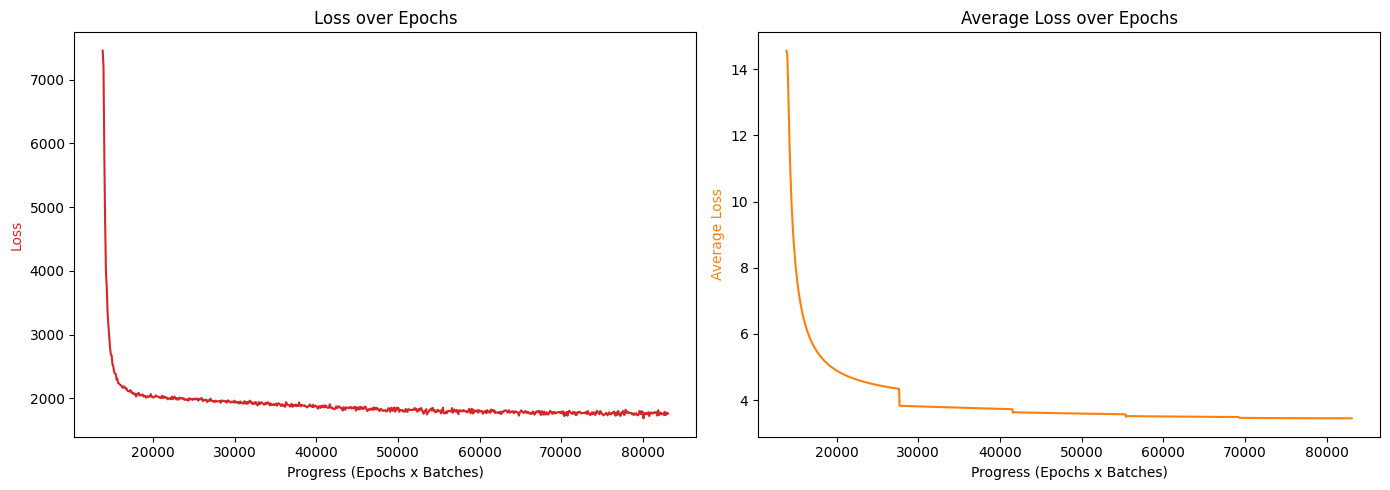

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax[0].plot(timestamps, losses, color='tab:red')
ax[0].set_xlabel('Progress (Epochs x Batches)')
ax[0].set_ylabel('Loss', color='tab:red')
ax[0].set_title('Loss over Epochs')

# Plot average Loss
ax[1].plot(timestamps, avg_losses, color='tab:orange', label='Avg Loss')
ax[1].set_xlabel('Progress (Epochs x Batches)')
ax[1].set_ylabel('Average Loss', color='tab:orange')
ax[1].set_title('Average Loss over Epochs')

plt.tight_layout()
plt.show()


In [3]:
words = ['man', 'woman', 'king', 'queen', 
         'apple', 'orange', 'fruit', 'banana', 'vegetable',
         'car', 'vehicle', 'computer', 'technology', 'bicycle',
         'dog', 'cat', 'animal', 'horse', 'cow', 'mammal',
         'country', 'city', 'village', 'house', 'building',
         'tree', 'flower', 'nature',
         'music', 'art', 'literature', 'philosophy', 'science',
         'love', 'happiness', 'sadness', 'emotion',
         'work', 'career', 'money', 'success',
         'eat', 'drink', 'food', 'water', 'meal',
         'run', 'walk', 'swim', 'fly', 'move',
         'happy', 'sad', 'angry', 'excited', 'bored',
         'fast', 'slow', 'hot', 'cold', 'weather',
         'day', 'night', 'morning', 'evening', 'time']

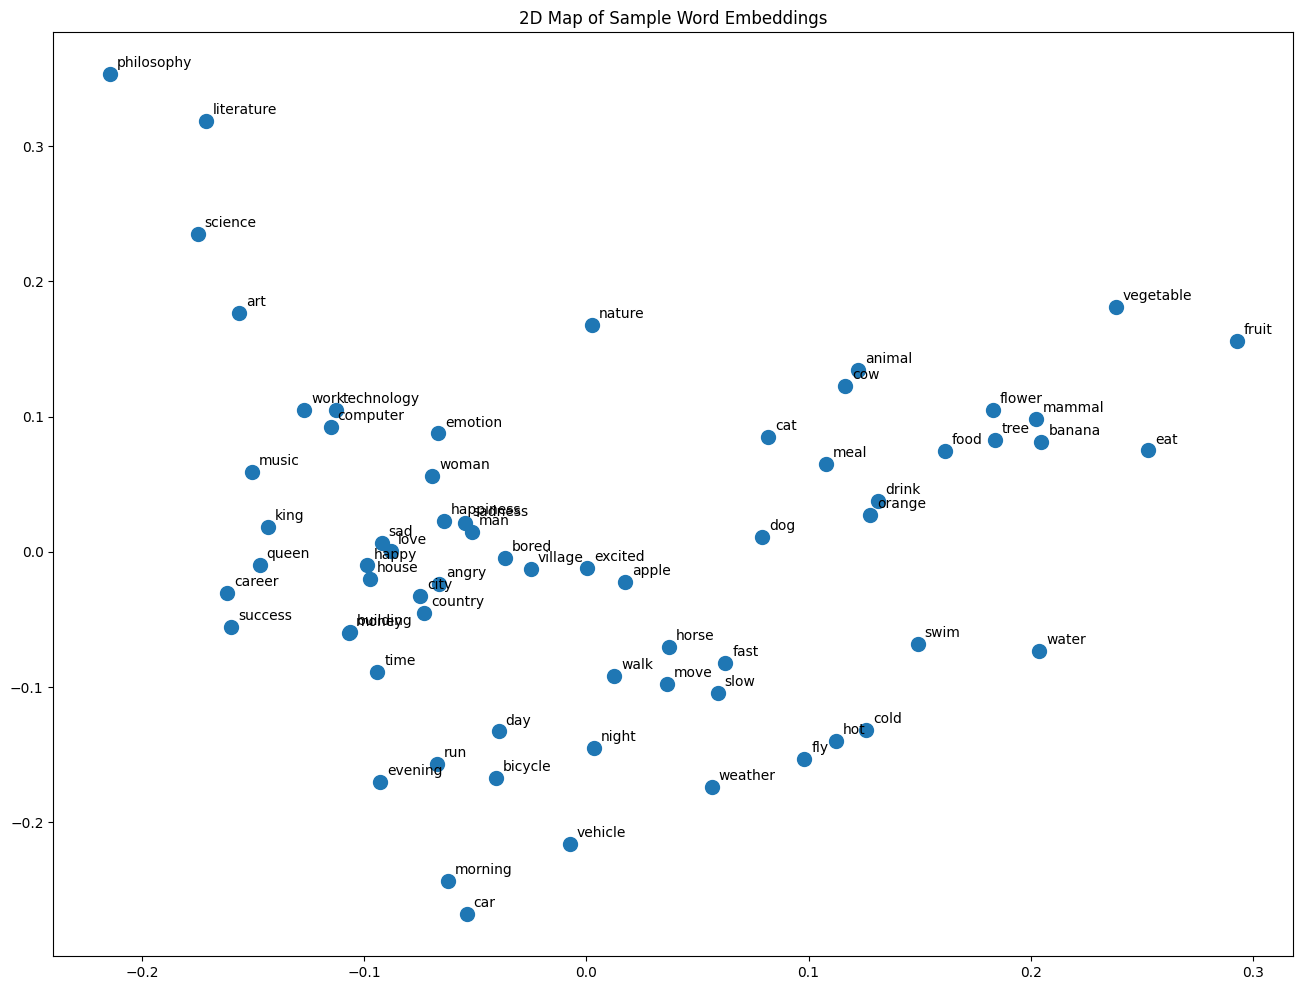

In [5]:
import numpy as np
U = np.load("artifacts/word_embeddings_U.npy")
with open("artifacts/vocabulary.txt", "r") as f:
    vocab = [line.strip() for line in f]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idxs = [word2idx[word] for word in words]
word_embeddings = U[idxs, :]

mean = np.mean(word_embeddings, axis=0)
centered = word_embeddings - mean
u, s, vh = np.linalg.svd(centered, full_matrices=False)
embeddings_2d = u[:, :2]

plt.figure(figsize=(16, 12))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='tab:blue', s=100)
for i, word in enumerate(words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=10)
plt.title("2D Map of Sample Word Embeddings")
plt.show()